##**AI-Powered Financial Fraud Detection & Risk Intelligence System**

##**Business Problem**

Banks and digital payment platforms process millions of financial transactions every day. Among these transactions, fraudulent activities cause significant financial losses, damage customer trust, and increase operational costs.

Traditional rule-based fraud detection systems often fail to identify new fraud patterns and may generate a large number of false alarms.

The objective of this project is to develop a Machine Learning-based fraud detection system that can accurately identify fraudulent transactions while minimizing false positives and false negatives.

##**IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
%matplotlib inline

In [2]:
df = pd.read_csv("/content/Project E$  (4).csv")

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0,0


##**EDA**

In [4]:
df.shape

(1048575, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [8]:
df.describe(include="object")

,type,nameOrig,nameDest
count,1048575,1048575,1048575
unique,5,1048317,449635
top,CASH_OUT,C443816828,C985934102
freq,373641,2,98


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [10]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [11]:
df.duplicated().sum()

np.int64(0)

##**Target Distribution**

In [12]:
df["isFraud"].value_counts()

,count
isFraud,
0,1047433
1,1142


In [13]:
df["isFraud"].value_counts(normalize=True)*100

,proportion
isFraud,
0,99.89109
1,0.10891


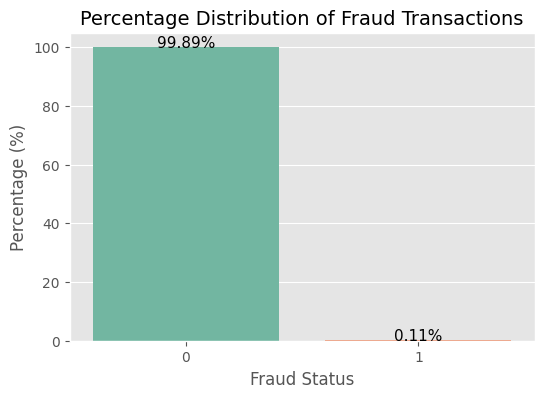

In [14]:
fraud_percent = df["isFraud"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=fraud_percent.index.astype(str),
    y=fraud_percent.values,
    palette="Set2"
)

plt.title("Percentage Distribution of Fraud Transactions", fontsize=14)
plt.xlabel("Fraud Status")
plt.ylabel("Percentage (%)")

for i, v in enumerate(fraud_percent.values):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=11)

plt.show()

## Initial Observations

- The dataset contains over 1 million financial transactions.
- No missing values were found in the dataset.
- No duplicate records were detected.
- The target variable (`isFraud`) is highly imbalanced.
- Around **99.89%** of transactions are legitimate, while only **0.11%** are fraudulent.
- This class imbalance must be considered during model development to avoid biased predictions.

##**Univariate Analysis**

**Type**

In [15]:
df["type"].value_counts()

,count
type,
CASH_OUT,373641
PAYMENT,353873
CASH_IN,227130
TRANSFER,86753
DEBIT,7178


In [16]:
round(df["type"].value_counts(normalize=True) * 100, 2)

,proportion
type,
CASH_OUT,35.63
PAYMENT,33.75
CASH_IN,21.66
TRANSFER,8.27
DEBIT,0.68


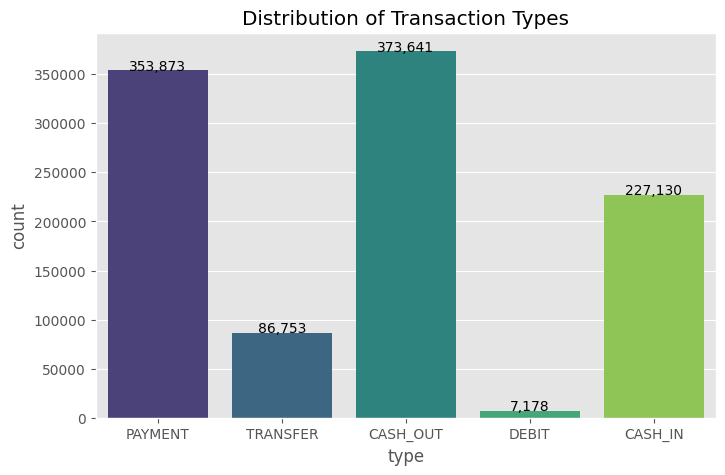

In [17]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="type", palette="viridis")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center")

plt.title("Distribution of Transaction Types")
plt.show()

### Observation

- CASH_OUT is the most common transaction type with **373,641** transactions.
- PAYMENT is the second most frequent transaction type with **353,873** transactions.
- CASH_IN also represents a significant portion of the transactions.
- TRANSFER transactions are comparatively lower (**86,753**).
- DEBIT transactions are the least frequent (**7,178**).
- The distribution of transaction types is not uniform across the dataset.

##**Transaction Type vs Fraud**

In [18]:
# Fraud count in each transaction type
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353873,0
TRANSFER,86189,564


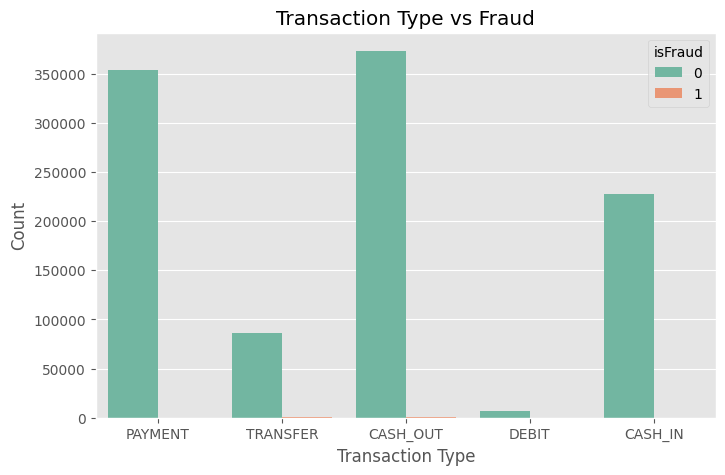

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="type",hue="isFraud",palette="Set2")
plt.title("Transaction Type vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

##**Amount**

In [20]:
df["amount"].describe()

,amount
count,1.048575e+06
mean,1.586670e+05
std,2.649409e+05
min,1.000000e-01
25%,1.214907e+04
50%,7.634333e+04
75%,2.137619e+05
max,1.000000e+07


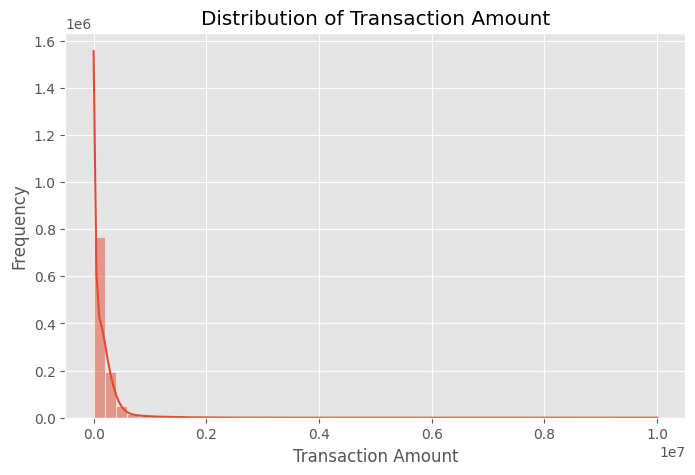

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

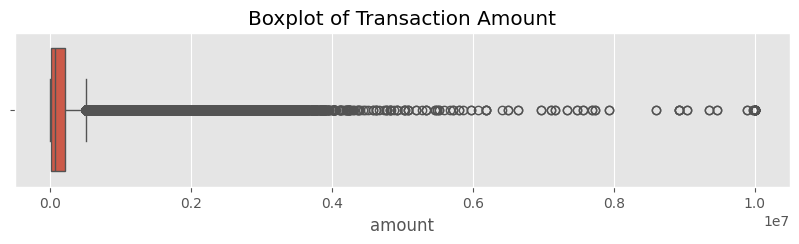

In [22]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [23]:
df["amount"].skew()

np.float64(6.374165698763262)

### Observation

- The transaction amount is highly right-skewed.
- Most transactions involve relatively small amounts.
- A few transactions contain extremely large values, creating a long right tail.
- The boxplot reveals a large number of potential outliers.
- The skewness value (6.37) confirms that the feature is highly positively skewed.

### Decision

✅ Missing Values → No

✅ Highly Skewed → Yes

✅ Outliers Present → Yes

🟡 Remove Outliers → Decision Pending

🟡 Scaling Required → Yes

##**Amount vs isFraud**

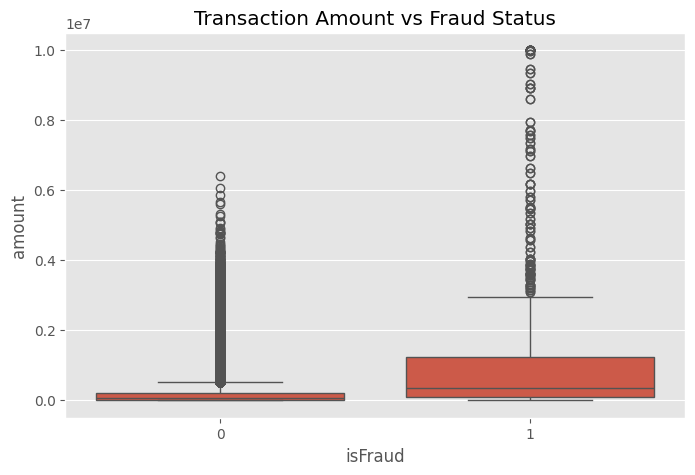

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.title("Transaction Amount vs Fraud Status")

plt.show()

##**Step**

In [25]:
df["step"].describe()

,step
count,1.048575e+06
mean,2.696617e+01
std,1.562325e+01
min,1.000000e+00
25%,1.500000e+01
50%,2.000000e+01
75%,3.900000e+01
max,9.500000e+01


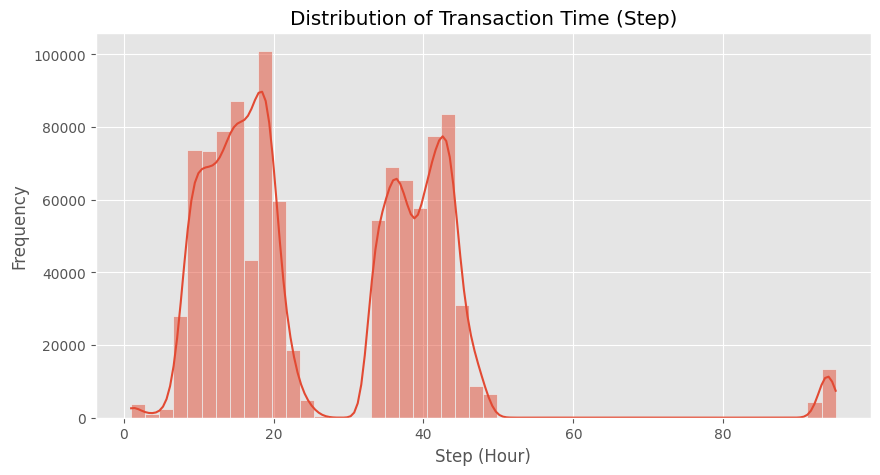

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(df["step"], bins=50, kde=True)

plt.title("Distribution of Transaction Time (Step)")
plt.xlabel("Step (Hour)")
plt.ylabel("Frequency")

plt.show()

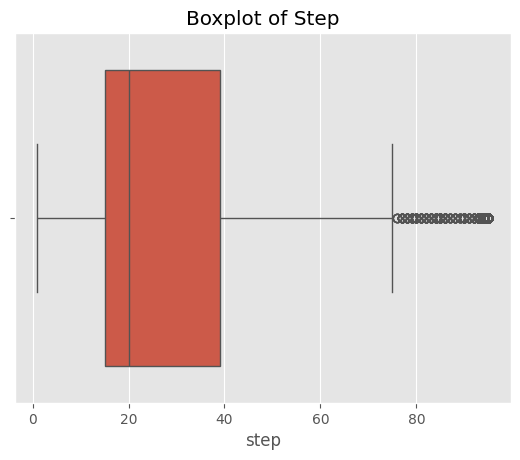

In [27]:
sns.boxplot(x=df["step"])

plt.title("Boxplot of Step")

plt.show()

In [28]:
df["step"].skew()

np.float64(1.294454639122211)

### Observation

- The `step` feature ranges from **1 to 95 hours**.
- The average transaction time is **26.97 hours**, while the median is **20 hours**.
- The distribution is positively skewed (Skewness = 1.294).
- The histogram shows multiple peaks, indicating that transactions are concentrated during specific time periods rather than being uniformly distributed.
- A few transactions occur during later hours, which appear as outliers in the boxplot.

### Decision

✅ Missing Values → No

✅ Highly Skewed → Yes

❌ Remove Outliers → No (Valid Time Values)

🟡 Scaling → Not Required for Tree Models

✅ Useful Feature → Yes

##**BIVARIATE ANALYSIS**

**Sender Balance Before Transaction vs Fraud Status**

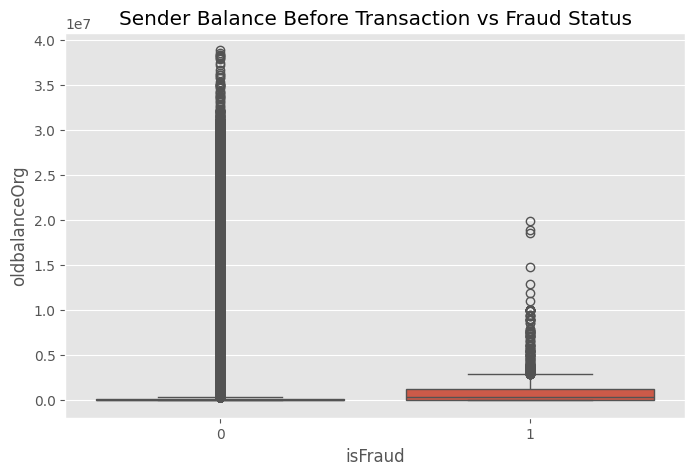

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceOrg"
)

plt.title("Sender Balance Before Transaction vs Fraud Status")

plt.show()

In [30]:
df.groupby("isFraud")["oldbalanceOrg"].agg(["mean","median","min","max"])

,mean,median,min,max
isFraud,,,,
0,8.736338e+05,15937.000,0.0,38900000.0
1,1.218636e+06,348705.145,0.0,19900000.0


### Observation

- Fraudulent transactions have a significantly higher median sender balance than genuine transactions.
- The median sender balance for fraud transactions is ₹348,705 compared to ₹15,937 for genuine transactions.
- The average sender balance is also higher in fraudulent transactions.
- This suggests that fraudsters often target or operate from accounts with higher available balances.

In [31]:
balance_features = ["oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

df[balance_features].describe().T

,count,mean,std,min,25%,50%,75%,max
oldbalanceOrg,1048575.0,8.740095e+05,2.971751e+06,0.0,0.0,16002.00,136642.020,38900000.0
newbalanceOrig,1048575.0,8.938089e+05,3.008271e+06,0.0,0.0,0.00,174599.990,38900000.0
oldbalanceDest,1048575.0,9.781600e+05,2.296780e+06,0.0,0.0,126377.21,915923.475,42100000.0
newbalanceDest,1048575.0,1.114198e+06,2.416593e+06,0.0,0.0,218260.36,1149807.510,42200000.0


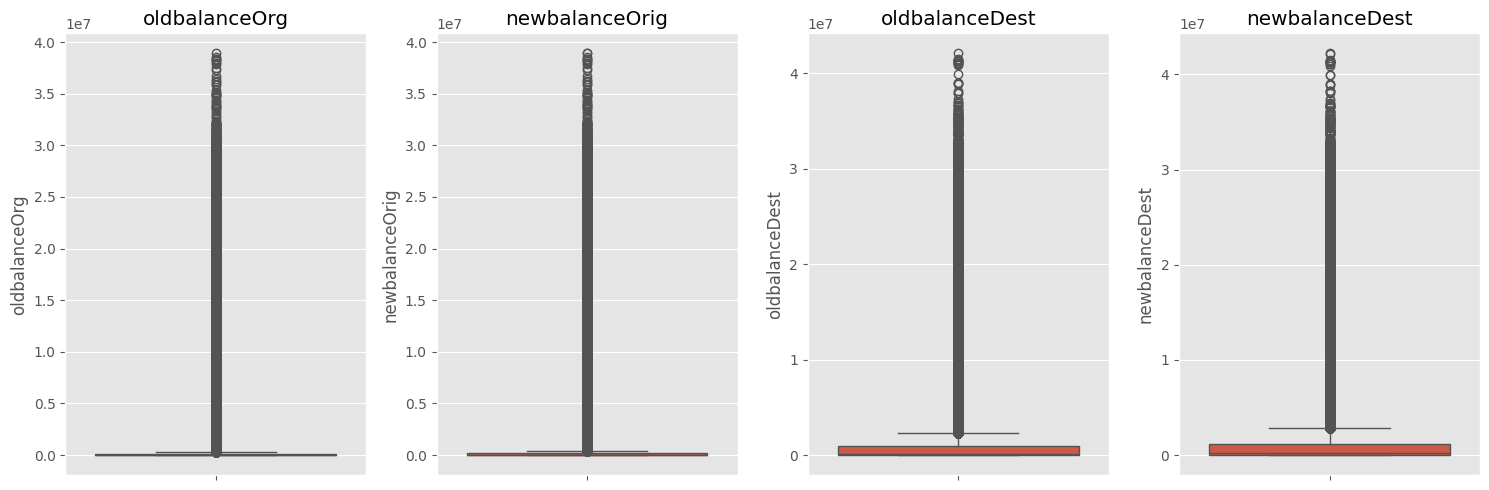

In [32]:
plt.figure(figsize=(15,5))

for i,col in enumerate(balance_features,1):
    plt.subplot(1,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [33]:
df[balance_features].skew().sort_values(ascending=False)

,0
oldbalanceDest,5.373195
oldbalanceOrg,5.124286
newbalanceOrig,5.060456
newbalanceDest,5.012456


In [34]:
df.groupby("isFraud")[balance_features].agg(["mean","median"])

oldbalanceOrg             newbalanceOrig        oldbalanceDest  \
                 mean      median           mean median           mean   
isFraud                                                                  
0        8.736338e+05   15937.000  894746.395080    0.0  978732.769117   
1        1.218636e+06  348705.145   33944.321208    0.0  452866.124527   

                   newbalanceDest              
            median           mean      median  
isFraud                                        
0        126863.76   1.114237e+06  218484.080  
1             0.00   1.077940e+06   13798.765

### Observation

• All balance-related features contain a large number of outliers.

• All balance features are highly positively skewed.

• Fraudulent transactions generally have a higher sender balance before the transaction (oldbalanceOrg).

• Fraudulent transactions often leave the sender account with a very low or zero balance after the transaction (newbalanceOrig).

• Receiver balances also show noticeable differences between fraudulent and genuine transactions.

• Balance-related features appear to be strong predictors for fraud detection.

### Decision

✅ Missing Values → No

✅ Outliers → Present

✅ Skewed Distribution → Yes

❌ Remove Outliers → No

🟡 Scaling → Later

✅ Feature Engineering Required → Yes

**Correlation Check**

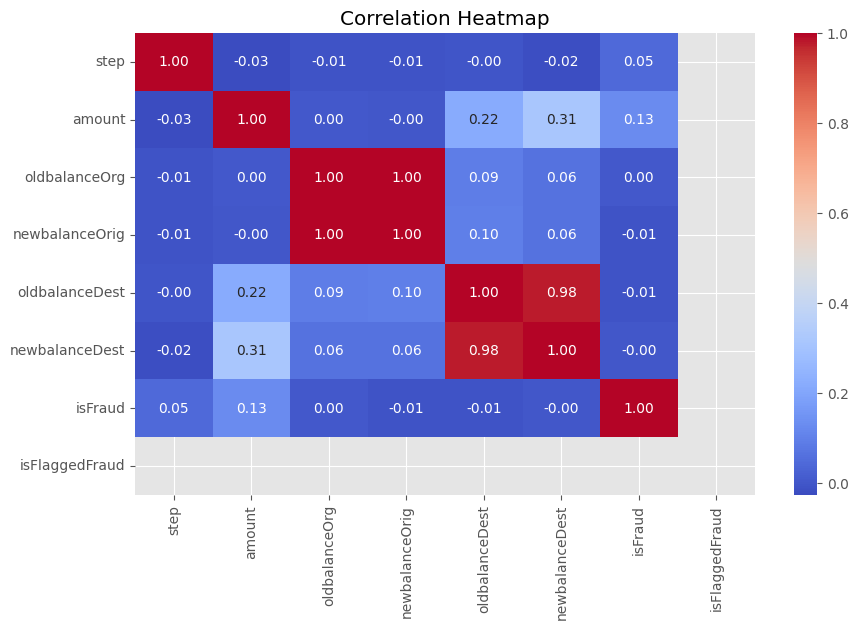

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

- Sender balance before and after the transaction are highly correlated.
- Receiver balance before and after the transaction also show a strong positive correlation.
- Transaction amount has a moderate positive correlation with the receiver's new balance.
- The target variable (`isFraud`) has low linear correlation with individual features.
- Fraud detection is likely to depend on the combined interaction of multiple features rather than a single feature.

##**EDA Summary**

- Dataset contains more than 1 million financial transactions.
- No missing values or duplicate records were found.
- The target variable is highly imbalanced.
- Fraud occurs primarily in CASH_OUT and TRANSFER transactions.
- Transaction amount is highly right-skewed and contains many outliers.
- Balance-related features are highly skewed and contain significant outliers.
- Sender and receiver balance features exhibit strong correlations.
- Individual features show weak linear correlation with the target, indicating that fraud detection depends on complex feature interactions.

##**DATA PREPROCCESING**

**Feature Engineering**

In [36]:
# FEATURE 1
df["sender_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [37]:
# FEATURE 2
df["expected_sender_balance"] = df["oldbalanceOrg"] - df["amount"]

In [38]:
# FEATURE 3
df["sender_balance_error"] = (df["expected_sender_balance"]- df["newbalanceOrig"])

In [39]:
# FEATURE 4
df["receiver_balance_diff"] = (df["newbalanceDest"]- df["oldbalanceDest"])

In [40]:
df[["sender_balance_diff","expected_sender_balance","sender_balance_error","receiver_balance_diff"]].sample(10)

,sender_balance_diff,expected_sender_balance,sender_balance_error,receiver_balance_diff
500713,-82486.20,795067.94,-164972.40,-104607.03
881442,51979.00,-325771.76,-325771.76,377750.76
657417,0.00,-107453.44,-107453.44,107453.45
597564,0.00,-22709.63,-22709.63,0.00
782483,-44947.96,-30225.96,-89895.92,-236.00
274953,55281.00,-313683.07,-313683.07,368964.08
629043,5044.00,-122841.13,-122841.13,127885.13
284174,0.00,-114760.05,-114760.05,114760.05
587255,33354.00,-215095.59,-215095.59,248449.59
408043,189028.29,-459284.02,-459284.02,422447.44


In [41]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'sender_balance_diff', 'expected_sender_balance',
       'sender_balance_error', 'receiver_balance_diff'],
      dtype='object')

Humne feature engineering baseline model se pehle kar di.
Koi problem nahi. Ye learning ka part hai.
Abhi hum un features ko drop kar dete hain. Baad me experiment ke liye dubara banayenge

In [42]:
df.drop(columns=[
    "sender_balance_diff",
    "expected_sender_balance",
    "sender_balance_error",
    "receiver_balance_diff"
], inplace=True)

##**Base Line Model To Before Feature Engineering to Make Feature Engineering Efficient**

In [43]:
#drop useless columns
df.drop(columns=["nameOrig","nameDest","isFlaggedFraud"], inplace=True)

In [44]:
df["type"].value_counts()

,count
type,
CASH_OUT,373641
PAYMENT,353873
CASH_IN,227130
TRANSFER,86753
DEBIT,7178


**One Hot Encoding**

In [45]:
df = pd.get_dummies(df, columns=["type"], drop_first=True, dtype=int)

In [46]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

**Train/Test/Split**

In [47]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**SCALING**

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**BASE LINE MODEL**

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

models={
    "Logistic Regression":LogisticRegression(random_state=42),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42,eval_metric="logloss")
}

In [51]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

results=[]

for name,model in models.items():

    if name=="Logistic Regression":
        model.fit(X_train_scaled,y_train)
        y_pred=model.predict(X_test_scaled)
        y_prob=model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train,y_train)
        y_pred=model.predict(X_test)
        y_prob=model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ])

results=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"])
results.sort_values("F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.999719,0.951872,0.780702,0.857831,0.983608
2,Random Forest,0.999723,0.988506,0.754386,0.855721,0.971035
1,Decision Tree,0.999542,0.808411,0.758772,0.782805,0.879288
0,Logistic Regression,0.999080,1.000000,0.153509,0.266160,0.926112
3,Gradient Boosting,0.997783,0.188976,0.315789,0.236453,0.551188


### Baseline Model Comparison

- XGBoost achieved the highest Recall (78.07%), F1 Score (85.78%), and ROC-AUC (98.36%).
- Random Forest delivered performance close to XGBoost and serves as a strong alternative.
- Decision Tree produced reasonable results but was less stable than ensemble methods.
- Logistic Regression failed to capture the minority class due to severe class imbalance.
- Gradient Boosting showed poor performance with default parameters, indicating that it is not well suited for this highly imbalanced dataset without tuning.

##**XGBoost Selected Now Improvement Begins**

In [63]:
from xgboost import XGBClassifier

xgb=XGBClassifier(random_state=42,eval_metric="logloss")

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

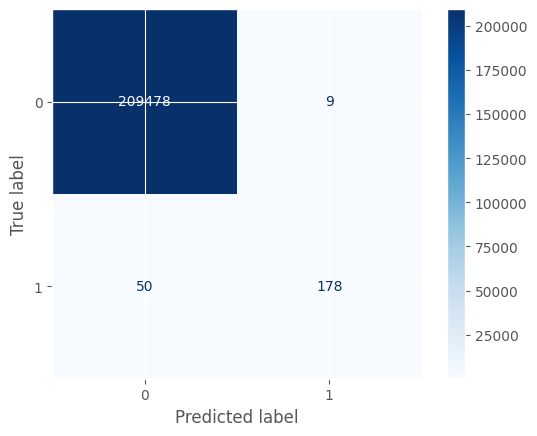

In [64]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.95      0.78      0.86       228

    accuracy                           1.00    209715
   macro avg       0.98      0.89      0.93    209715
weighted avg       1.00      1.00      1.00    209715



**Model depend on which feature**

In [66]:
importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":xgb.feature_importances_
})

importance = importance.sort_values("Importance",ascending=False)

importance

,Feature,Importance
5,newbalanceDest,0.289959
6,type_CASH_OUT,0.226002
9,type_TRANSFER,0.106527
3,newbalanceOrig,0.100854
0,step,0.084367
2,oldbalanceOrg,0.081128
1,amount,0.052934
4,oldbalanceDest,0.048054
8,type_PAYMENT,0.010175
7,type_DEBIT,0.000000


##**Optimization Phase**

**Hyperparameter Tuning**

In [86]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [87]:
xgb = XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,min_child_weight=5,gamma=0.1,random_state=42,eval_metric="logloss",n_jobs=-1)

In [88]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [89]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

In [90]:
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

Accuracy : 0.999756812817395
Precision: 0.988950276243094
Recall   : 0.7850877192982456
F1 Score : 0.8753056234718827
ROC AUC  : 0.9956252362182337


In [91]:
train_pred = xgb.predict(X_train)
train_prob = xgb.predict_proba(X_train)[:,1]

print("Train Accuracy :",accuracy_score(y_train,train_pred))
print("Train Precision:",precision_score(y_train,train_pred))
print("Train Recall   :",recall_score(y_train,train_pred))
print("Train F1 Score :",f1_score(y_train,train_pred))
print("Train ROC AUC  :",roc_auc_score(y_train,train_prob))

Train Accuracy : 0.999835491023532
Train Precision: 0.9974358974358974
Train Recall   : 0.8512035010940919
Train F1 Score : 0.9185360094451004
Train ROC AUC  : 0.9985064108594683


### Overfitting Reduction Experiment

A more conservative XGBoost configuration was tested by reducing tree depth and increasing the minimum child weight.

The change did not produce a meaningful improvement in generalization performance. Therefore, the previous tuned XGBoost model was retained as the final candidate model.

**Threshold Tunning**

In [92]:
from sklearn.metrics import precision_score,recall_score,f1_score
thresholds=[0.30,0.35,0.40,0.45,0.50,0.55,0.60]
results=[]
for t in thresholds:
    pred=(y_prob>=t).astype(int)
    results.append([
        t,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)])

threshold_df=pd.DataFrame(results,columns=["Threshold","Precision","Recall","F1 Score"])
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.958549,0.811404,0.878860
1,0.35,0.973684,0.811404,0.885167
2,0.40,0.978610,0.802632,0.881928
3,0.45,0.989071,0.793860,0.880779
4,0.50,0.988950,0.785088,0.875306
5,0.55,0.988889,0.780702,0.872549
6,0.60,0.994350,0.771930,0.869136


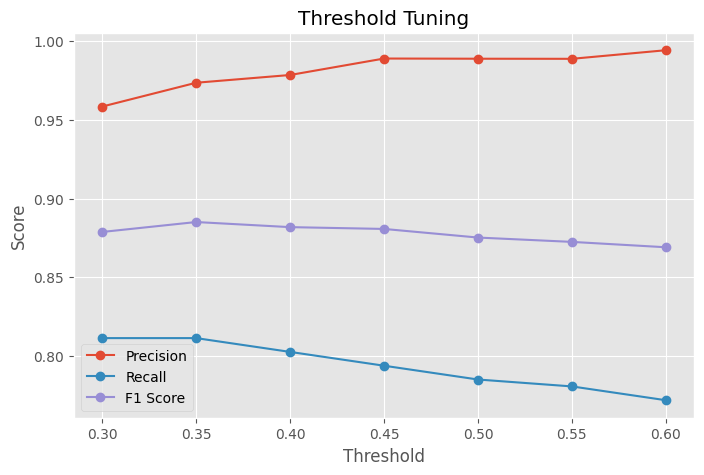

In [93]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"],threshold_df["Precision"],marker="o",label="Precision")
plt.plot(threshold_df["Threshold"],threshold_df["Recall"],marker="o",label="Recall")
plt.plot(threshold_df["Threshold"],threshold_df["F1 Score"],marker="o",label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

plt.show()

XGBoost outputs probabilities by default and uses a threshold of 0.5 for classification. Since fraud detection requires a balance between Precision and Recall, I evaluated multiple thresholds and selected 0.35 because it produced the highest F1 Score while improving Recall with only a small reduction in Precision.

**Final Prediction (Threshold = 0.35)**

In [94]:
threshold = 0.35

y_pred_final = (y_prob >= threshold).astype(int)

**Final Confusion Matrix**

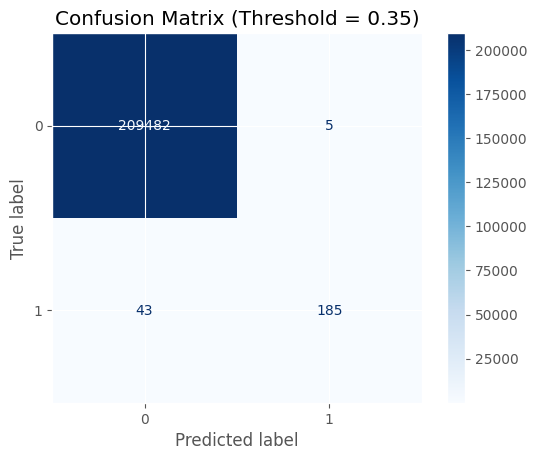

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.35)")
plt.show()

**Final Classification Report**

In [96]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.97      0.81      0.89       228

    accuracy                           1.00    209715
   macro avg       0.99      0.91      0.94    209715
weighted avg       1.00      1.00      1.00    209715



**Final Metrics**

In [98]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print("Accuracy :",accuracy_score(y_test,y_pred_final))
print("Precision:",precision_score(y_test,y_pred_final))
print("Recall   :",recall_score(y_test,y_pred_final))
print("F1 Score :",f1_score(y_test,y_pred_final))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

Accuracy : 0.9997711179457835
Precision: 0.9736842105263158
Recall   : 0.8114035087719298
F1 Score : 0.8851674641148325
ROC AUC  : 0.9956252362182337


## Threshold Optimization

The default decision threshold (0.50) was evaluated against multiple thresholds.

A threshold of **0.35** produced the highest F1 Score while improving Recall with only a small reduction in Precision.

Therefore, **0.35** was selected as the optimal decision threshold for the final fraud detection model.

###***SHAP Explanability***

**SHAP (SHapley Additive exPlanations)**

It explains why the model made a particular prediction by showing the contribution of each feature.

In [99]:
import shap
explainer = shap.TreeExplainer(xgb)

In [100]:
shap_values = explainer.shap_values(X_test)

**SHAP Summary Plot**

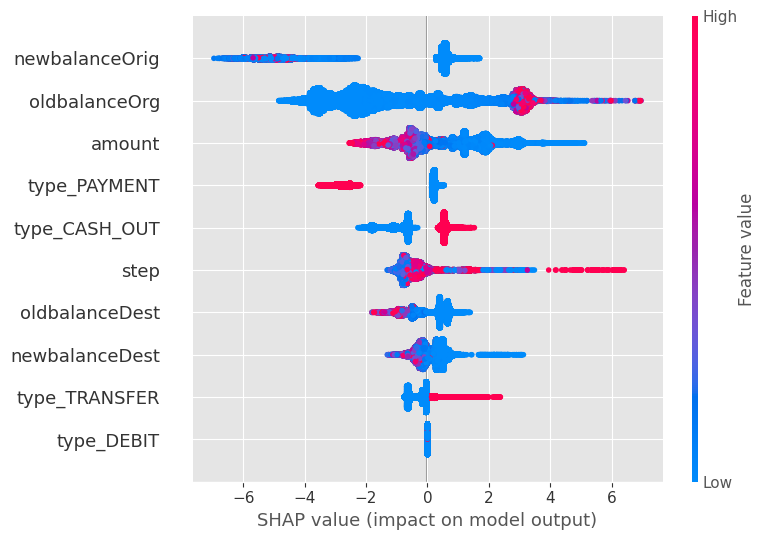

In [101]:
shap.summary_plot(shap_values, X_test)

The SHAP Summary Plot explains the global behavior of the XGBoost model. Each dot represents one transaction, the color indicates whether the feature value is high or low, and the horizontal position shows whether that feature pushes the prediction towards fraud or genuine transactions. It helps identify not only the most important features but also how they influence predictions.

**SHAP Waterfall Plot**

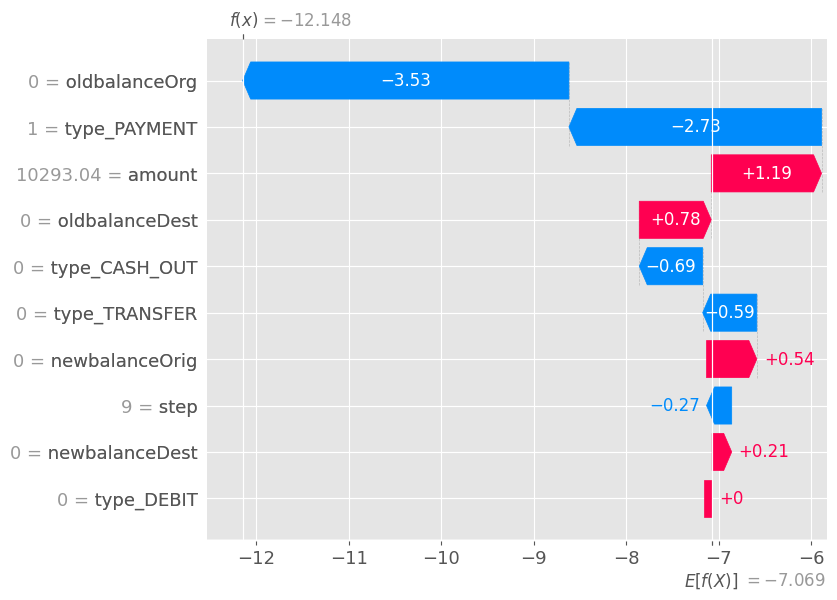

In [104]:
sample = 0

shap.plots.waterfall(shap.Explanation(values=shap_values[sample],base_values=explainer.expected_value,data=X_test.iloc[sample],feature_names=X_test.columns))